C:\Users\momo\AppData\Local\Temp\ipykernel_32044\969985485.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X_data = torch.tensor(X_data, dtype=torch.float32).unsqueeze(-1)


开始训练 RNN...
开始训练 LSTM...
开始训练 GRU...


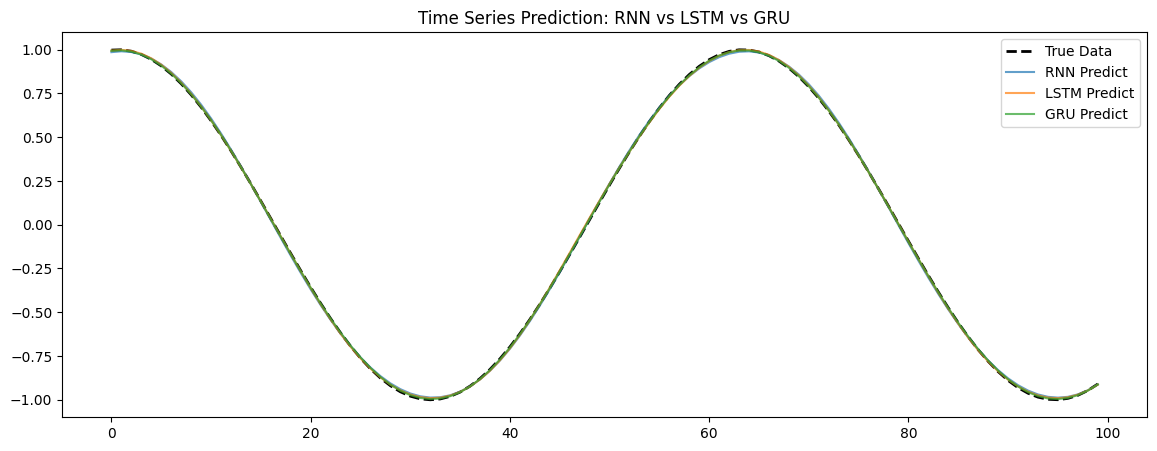


--- 模型参数量对比 ---
RNN  参数量: 1153
GRU  参数量: 3393
LSTM 参数量: 4513


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 准备时间序列数据 (正弦波)
# ==========================================
def create_dataset(seq_len=20, num_samples=1000):
    # 生成一个包含噪声的正弦波
    x = np.linspace(0, 50, num_samples)
    y = np.sin(x)
    
    X_data, Y_data = [],[]
    for i in range(len(y) - seq_len):
        X_data.append(y[i : i+seq_len])      # 用前 seq_len 个点
        Y_data.append(y[i+seq_len])          # 预测第 seq_len+1 个点
        
    # 转换形状为 (Batch, Sequence, Feature) -> 这里特征维度为1
    X_data = torch.tensor(X_data, dtype=torch.float32).unsqueeze(-1)
    Y_data = torch.tensor(Y_data, dtype=torch.float32).unsqueeze(-1)
    return X_data, Y_data

# ==========================================
# 2. 定义三种模型
# ==========================================

# 2.1 基础 RNN 模型
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        #输入数据的维度是 [batch_size, seq_len, feature]
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        #out形状为 [batch, seq_len, hidden_size], h_n是最后一个隐藏状态
        out, h_n = self.rnn(x) 
        #只利用序列最后一个时间步的输出去进行预测
        return self.fc(out[:, -1, :])

# 2.2 LSTM 模型
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # 【关键区别】：LSTM返回包含细胞状态 c_n 的元组 (h_n, c_n)
        out, (h_n, c_n) = self.lstm(x) 
        return self.fc(out[:, -1, :])

# 2.3 GRU 模型
class SimpleGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # GRU 的返回值和基础RNN一样，只有 out 和 h_n
        out, h_n = self.gru(x)
        return self.fc(out[:, -1, :])

# ==========================================
# 3. 训练和对比模块
# ==========================================
def train_model(model, X, Y, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    loss_history =[]
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X)
        loss = criterion(predictions, Y)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        
    return loss_history, predictions.detach().numpy()

if __name__ == '__main__':
    # 获取数据
    seq_len = 15
    X, Y = create_dataset(seq_len=seq_len, num_samples=500)
    
    # 实例化模型
    model_rnn = SimpleRNN()
    model_lstm = SimpleLSTM()
    model_gru = SimpleGRU()
    
    print("开始训练 RNN...")
    loss_rnn, pred_rnn = train_model(model_rnn, X, Y)
    
    print("开始训练 LSTM...")
    loss_lstm, pred_lstm = train_model(model_lstm, X, Y)
    
    print("开始训练 GRU...")
    loss_gru, pred_gru = train_model(model_gru, X, Y)
    
    # ==========================================
    # 4. 可视化结果
    # ==========================================
    plt.figure(figsize=(14, 5))
    
    # 绘制真实值与预测值的对比 (只取前100个点便于观察)
    plt.plot(Y.numpy()[:100], label='True Data', color='black', linewidth=2, linestyle='dashed')
    plt.plot(pred_rnn[:100], label='RNN Predict', alpha=0.7)
    plt.plot(pred_lstm[:100], label='LSTM Predict', alpha=0.7)
    plt.plot(pred_gru[:100], label='GRU Predict', alpha=0.7)
    
    plt.title('Time Series Prediction: RNN vs LSTM vs GRU')
    plt.legend()
    plt.show()

    # 打印参数量对比
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n--- 模型参数量对比 ---")
    print(f"RNN  参数量: {count_parameters(model_rnn)}")
    print(f"GRU  参数量: {count_parameters(model_gru)}")
    print(f"LSTM 参数量: {count_parameters(model_lstm)}")
